# 1. Import Library

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot") 

---
# 2. Read Data

In [ ]:
path = "mantis_hunting.csv"
df = pd.read_csv(path)

In [110]:
df.head()

,Humidity Level,Temperature,Time of Day,Luring Success,Time Spent Hunting,Prey Size,Ambush,Food Availability,Predator Presence,Is Competition,Hunting Success
0,0.32,31.25,Morning,True,0.81,6.600000,False,NaN,True,False,0
1,0.66,29.08,Afternoon,False,2.81,5.380000,False,Low,False,False,1
2,0.61,25.74,Evening,True,3.79,15.189246,True,Low,False,False,1
3,0.37,22.68,Morning,False,4.27,5.060000,True,Low,True,False,1
4,0.65,29.20,Afternoon,False,3.84,2.710000,False,High,False,False,1


---
# 3. Data Exploration

In [111]:
print("Data info")
df.info()

Data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Humidity Level      300000 non-null  float64
 1   Temperature         300000 non-null  float64
 2   Time of Day         300000 non-null  object 
 3   Luring Success      300000 non-null  bool   
 4   Time Spent Hunting  300000 non-null  float64
 5   Prey Size           300000 non-null  float64
 6   Ambush              300000 non-null  bool   
 7   Food Availability   269788 non-null  object 
 8   Predator Presence   270292 non-null  object 
 9   Is Competition      269881 non-null  object 
 10  Hunting Success     300000 non-null  int64  
dtypes: bool(2), float64(4), int64(1), object(4)
memory usage: 21.2+ MB


In [112]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

Number of rows: 300000
Number of columns : 11


In [113]:
print("Data types")
df.dtypes

Data types


Humidity Level        float64
Temperature           float64
Time of Day            object
Luring Success           bool
Time Spent Hunting    float64
Prey Size             float64
Ambush                   bool
Food Availability      object
Predator Presence      object
Is Competition         object
Hunting Success         int64
dtype: object

Text(0.5, 1.0, 'Hunting Success Distribution')

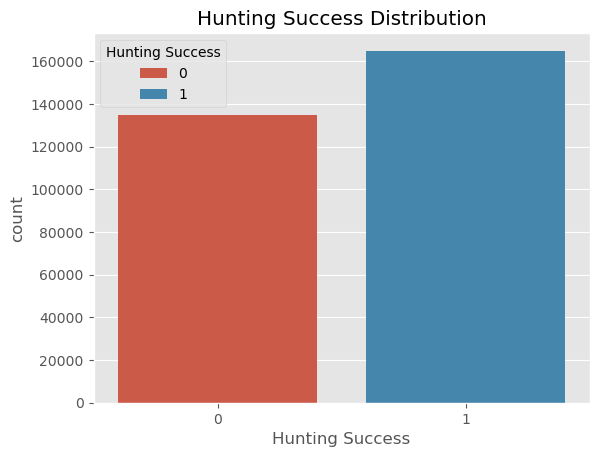

In [114]:
sns.countplot(data=df, x="Hunting Success", hue="Hunting Success")
plt.title("Hunting Success Distribution")

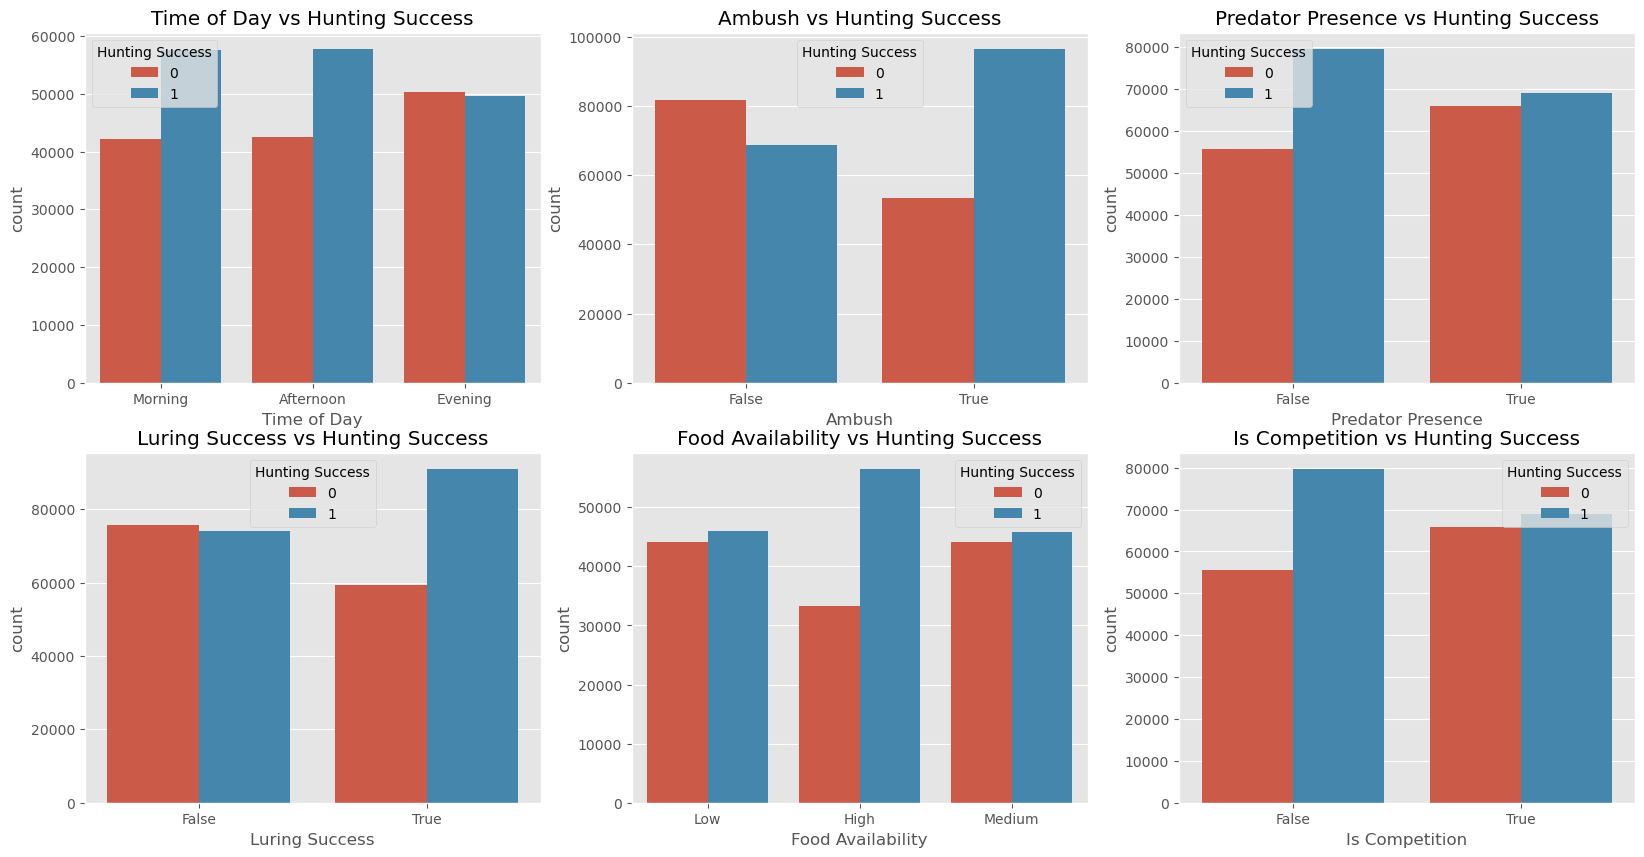

In [115]:
categorical_columns = [
    "Time of Day",
    "Luring Success",
    "Ambush",
    "Food Availability",
    "Predator Presence",
    "Is Competition",
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for idx, col in enumerate(categorical_columns):
    c = idx // 2
    r = idx % 2
    
    sns.countplot(data=df, x=col, hue="Hunting Success", ax=axes[r, c])
    axes[r, c].set_title(f"{col} vs Hunting Success")
plt.show()

In [116]:
print("Numeric Distribution")
df.describe()

Numeric Distribution


,Humidity Level,Temperature,Time Spent Hunting,Prey Size,Hunting Success
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,0.599884,27.498432,2.729269,5.662011,0.549857
std,0.173421,4.330176,1.406132,2.815613,0.497509
min,0.300000,20.000000,0.400000,1.000000,0.000000
25%,0.450000,23.750000,1.550000,3.310000,0.000000
50%,0.600000,27.490000,2.693402,5.590000,1.000000
75%,0.750000,31.250000,3.840000,7.880000,1.000000
max,0.900000,35.000000,10.189327,20.974719,1.000000


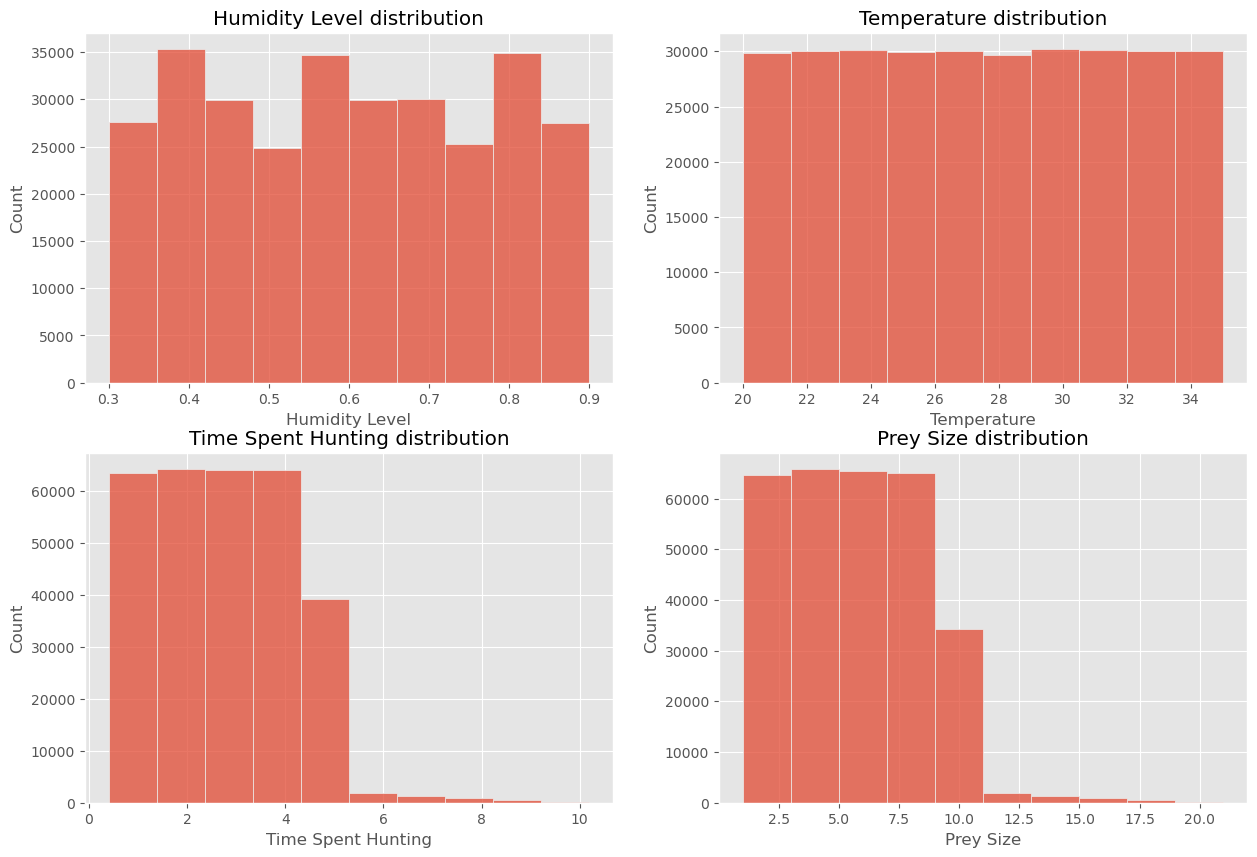

In [117]:
numeric_columns = [
    "Humidity Level",
    "Temperature",
    "Time Spent Hunting",
    "Prey Size"
]

fig, axes = plt.subplots(2, 2, figsize=(15,10))
for idx, col in enumerate(numeric_columns):
    r = idx // 2
    c = idx % 2
    
    sns.histplot(data=df, x=col, bins=10, kde=False, ax=axes[r][c])
    axes[r, c].set_title(f"{col} distribution")
plt.show()

---
# 4. Preprocessing

## 4.1 Handling missing value

In [118]:
missing_count = df.isnull().sum()

print("Missing value count")
print(missing_count)

Missing value count
Humidity Level            0
Temperature               0
Time of Day               0
Luring Success            0
Time Spent Hunting        0
Prey Size                 0
Ambush                    0
Food Availability     30212
Predator Presence     29708
Is Competition        30119
Hunting Success           0
dtype: int64


Text(0.5, 1.0, 'Missing value of each columns')

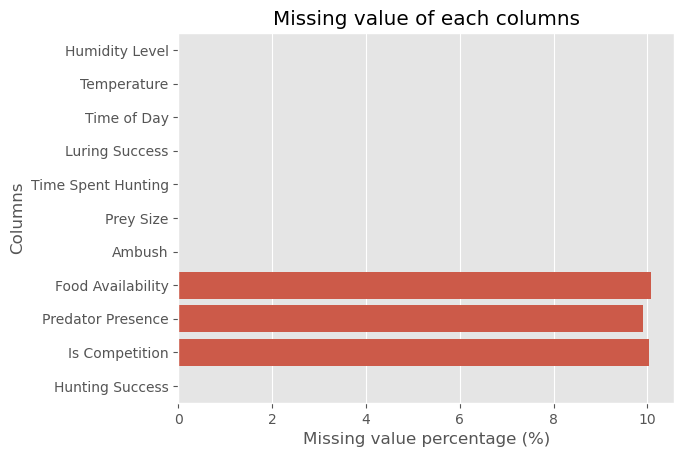

In [119]:
missing_percentage = missing_count / df.shape[0] * 100

sns.barplot(x=missing_percentage, y=missing_percentage.index)
plt.xlabel("Missing value percentage (%)")
plt.ylabel("Columns")
plt.title("Missing value of each columns")

We can see that three columns—`Food Availability`, `Predator Presence`, and `Is Competition` —have approximately 10% missing values, while the other columns have no missing data. To avoid changing the distribution of the original data, we will fill these missing values with `"unknown"`.

In [120]:
missing_columns = [
    "Food Availability",
    "Predator Presence",
    "Is Competition"
]

for col in missing_columns:
    df[col] = df[col].fillna("Unknown")

In [121]:
print("Missing value count after handling")
df.isnull().sum()

Missing value count after handling


Humidity Level        0
Temperature           0
Time of Day           0
Luring Success        0
Time Spent Hunting    0
Prey Size             0
Ambush                0
Food Availability     0
Predator Presence     0
Is Competition        0
Hunting Success       0
dtype: int64

## 4.2 Handling Categorical Columns

In [122]:
object_columns = df.select_dtypes(include="object").columns.tolist()
print(object_columns)

['Time of Day', 'Food Availability', 'Predator Presence', 'Is Competition']


In [123]:
for col in object_columns:
    print(f"{col} has {df[col].unique()}")

Time of Day has ['Morning' 'Afternoon' 'Evening']
Food Availability has ['Unknown' 'Low' 'High' 'Medium']
Predator Presence has [True False 'Unknown']
Is Competition has [False True 'Unknown']


We have four categorical columns:
- `Time of Day`: We can use Label Encoding because there is a natural order: Morning < Afternoon < Evening.
- `Food Availability`: Label Encoding can be applied with the order: Low < Unknown < Medium < High.
- `Predator Presence`: Label Encoding with the order: False < Unknown < True.
- `Is Competition`: Label Encoding with the order: False < Unknown < True.

NOTE We use the order False < Unknown < True because Unknown could represent either True or False, so we place it in the middle similar to `Food Availability`

In [124]:
print(df["Time of Day"].unique())

['Morning' 'Afternoon' 'Evening']


In [125]:
from sklearn.preprocessing import OrdinalEncoder

order_map = {
    "Time of Day": ["Morning", "Afternoon", "Evening"],
    "Food Availability": ["Low", "Unknown", "Medium", "High"],
    "Predator Presence": ["False", "Unknown", "True"],
    "Is Competition": ["False", "Unknown", "True"]
}

for col in order_map.keys():
    df[col] = df[col].astype(str).str.strip()

for col, order in order_map.items():
    encoder = OrdinalEncoder(categories=[order])
    df[col] = encoder.fit_transform(df[[col]]).ravel().astype(int)

In [126]:
print("5 first rows:")
df.head()

5 first rows:


,Humidity Level,Temperature,Time of Day,Luring Success,Time Spent Hunting,Prey Size,Ambush,Food Availability,Predator Presence,Is Competition,Hunting Success
0,0.32,31.25,0,True,0.81,6.600000,False,1,2,0,0
1,0.66,29.08,1,False,2.81,5.380000,False,0,0,0,1
2,0.61,25.74,2,True,3.79,15.189246,True,0,0,0,1
3,0.37,22.68,0,False,4.27,5.060000,True,0,2,0,1
4,0.65,29.20,1,False,3.84,2.710000,False,3,0,0,1


## 4.3 Feature Selection

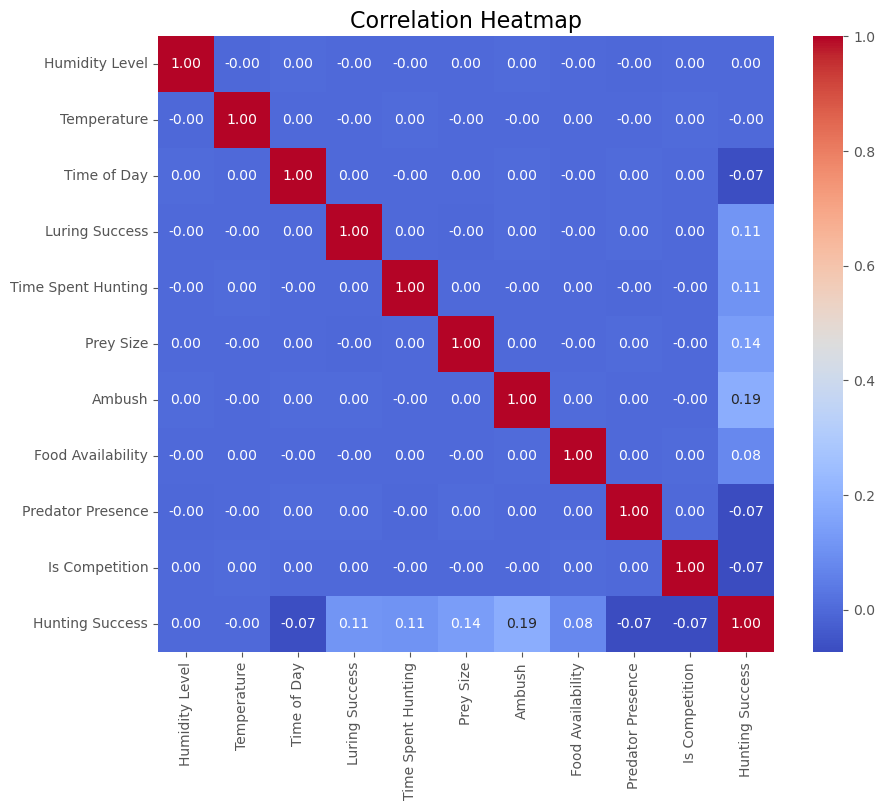

In [127]:
# Compute correlation of all columns
corr = df.corr()
# Draw heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

The correlations of all columns with the target are very low (ranging from -0.07 to 0.19), indicating weak relationships. Therefore, we should include all these features in the final model.

---
# 5. Split the dataset into training, validation, and test sets

In [128]:
# Divide df into X and y
X, y = df.drop(["Hunting Success"], axis=1), df["Hunting Success"]

In [129]:
from sklearn.model_selection import train_test_split

# split original set into train and temp set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.6, random_state=100)
#split temp set into validation and test set
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=100)

In [130]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (180000, 10), y_train shape: (180000,)
X_val shape: (60000, 10), y_val shape: (60000,)
X_test shape: (60000, 10), y_test shape: (60000,)


---
# 6. XGBoost vs CatBoost

In [131]:
# XGBoostClassfier
from xgboost import XGBClassifier
# CatBoostClassifier
from catboost import CatBoostClassifier
# Evaluate
from sklearn.metrics import accuracy_score

In [132]:
def plot_error_curve(X=[], y=[], x_label="", y_label="", title=""):
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=X, y=y)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()


In [179]:
def plot_confusion_matrix(y_test, y_predict, title="Confusion Matrix", ax=None):
    cm = confusion_matrix(y_test, y_predict)
    classes = np.unique(np.concatenate([y_test, y_predict]))
    
    if ax is None:
        plt.figure(figsize=(4, 4))
        ax = plt.gca()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                cbar=False, square=True, ax=ax)
    
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")
    ax.set_title(title)

## 6.1 XGBoost

In [134]:
def compute_xgboost_errors(learning_rates=[], estimators=[], max_depths=[]):
    errors = []
    
    for lr, est, md in zip(learning_rates, estimators, max_depths):
        # Build XGBClassifier with seed=100
        model_xgboost = XGBClassifier(
            n_estimators=est,
            max_depth=md,
            learning_rate=lr,
            seed=100
        )
        model_xgboost.fit(X_train, y_train)
        y_predict = model_xgboost.predict(X_val)
        
        accuracy = accuracy_score(y_predict, y_val)
        errors.append(1 - accuracy)
        
    return errors

### 6.1.1 XGBoost: Effect of learning rate

First, to determine a suitable learning rate for the subsequent steps, we compare five different learning rates using n_estimators=100 and max_depth=6 (default) to find the value that minimizes the error. This optimal learning rate is then used for the remaining processes.

In [135]:
learning_rates = [0.01, 0.05, 0.1, 0.3, 0.5]
estimators = [100] * len(learning_rates)
max_depths = [6] * len(learning_rates)

learning_rate_errors = compute_xgboost_errors(
    learning_rates=learning_rates,
    estimators=estimators,
    max_depths=max_depths
)

In [136]:
for idx, e in enumerate(learning_rate_errors):
    print(f"With learning rate: {learning_rates[idx]}, accuracy: {(1 - e) * 100:.3f}%")

With learning rate: 0.01, accuracy: 95.070%
With learning rate: 0.05, accuracy: 97.260%
With learning rate: 0.1, accuracy: 97.297%
With learning rate: 0.3, accuracy: 97.262%
With learning rate: 0.5, accuracy: 97.182%


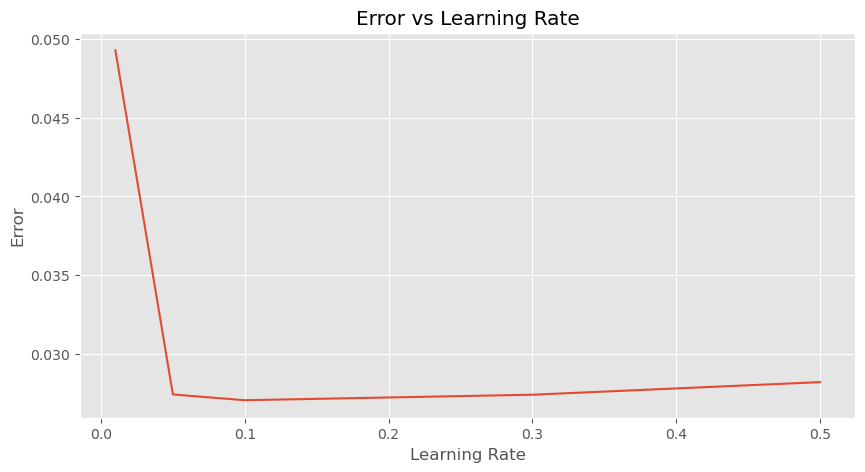

In [137]:
plot_error_curve(
    X=learning_rates,
    y=learning_rate_errors,
    x_label="Learning Rate",
    y_label="Error",
    title="Error vs Learning Rate"
)

In [138]:
xg_lr = 0.1 # The best learning rate

As we can see, the error is highest at a learning rate of 0.01, then decreases and reaches its lowest value at lr = 0.1. After that, the error increases slightly at lr = 0.3 and lr = 0.5. Therefore, we will use lr = 0.1 for the subsequent steps.

### 6.1.2 XGBoost: Effect of n_estimators
In this section, we compare the effect of different n_estimators using the learning rate lr = 0.1 (selected in the previous section) and the default max_depth = 6.

In [139]:
estimators = [10, 50, 100, 150, 300]
learning_rates = [xg_lr] * len(estimators)
max_depths = [6] * len(estimators)

est_errors = compute_xgboost_errors(
    learning_rates=learning_rates,
    estimators=estimators,
    max_depths=max_depths
)

In [140]:
for idx, e in enumerate(est_errors):
    print(f"With n_estimators: {estimators[idx]}, accuracy: {(1 - e) * 100:.3f}%")

With n_estimators: 10, accuracy: 95.158%
With n_estimators: 50, accuracy: 97.292%
With n_estimators: 100, accuracy: 97.297%
With n_estimators: 150, accuracy: 97.298%
With n_estimators: 300, accuracy: 97.248%


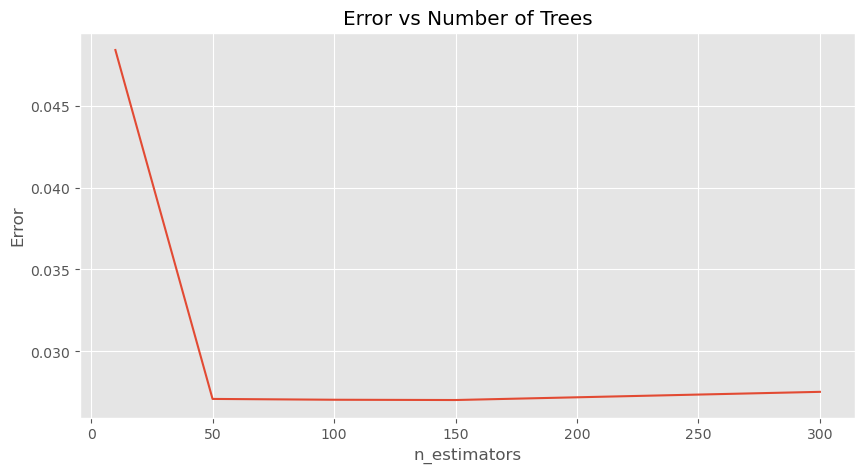

In [141]:
plot_error_curve(
    X=estimators,
    y=est_errors,
    x_label="n_estimators",
    y_label="Error",
    title="Error vs Number of Trees"
)

In [142]:
xg_est = 50 # The best number of trees

As we can see, the error is highest when n_estimators = 10, then drops significantly and reaches its lowest value at n_estimators = 50. After that, the error remains nearly unchanged for 100, 150, and 300 trees. Therefore, we will use n_estimators = 50 for the subsequent steps.

### 6.1.3 XGBoost: Effect of max_depth

In this step, we compare the XGBoost model using different values of max_depth, with n_estimators = 50 and learning_rate = 0.1 (selected in the previous section).

In [143]:
max_depths = [3, 4, 6, 8, 10]
learning_rates = [xg_lr] * len(max_depths)
estimators = [xg_est] * len(max_depths)

md_errors = compute_xgboost_errors(
    learning_rates=learning_rates,
    estimators=estimators,
    max_depths=max_depths
)

In [144]:
for idx, e in enumerate(md_errors):
    print(f"With max_depth: {max_depths[idx]}, accuracy: {(1 - e) * 100:.3f}%")

With max_depth: 3, accuracy: 95.318%
With max_depth: 4, accuracy: 97.278%
With max_depth: 6, accuracy: 97.292%
With max_depth: 8, accuracy: 97.268%
With max_depth: 10, accuracy: 97.243%


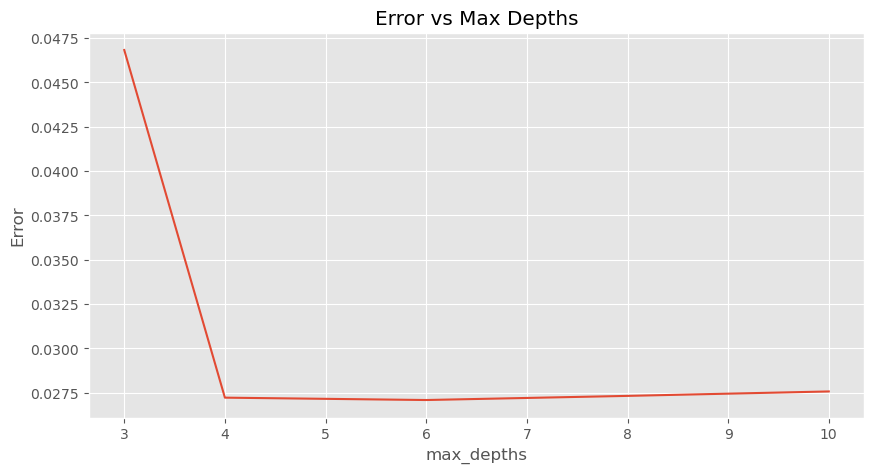

In [145]:
plot_error_curve(
    X=max_depths,
    y=md_errors,
    x_label="max_depths",
    y_label="Error",
    title="Error vs Max Depths"
)

In [146]:
xg_md = 6 # The best max_depth

As we can see, the error is highest when max_depth = 3, then decreases and reaches its lowest value at max_depth = 6. After that, the error increases slightly for max_depth = 8 and max_depth = 10. Therefore, we will use max_depth = 6 for the subsequent steps.

### 6.1.4 Best model of XGBoost

In [184]:
model_xgboost = XGBClassifier(
    n_estimators=xg_est,
    max_depth=xg_md,
    learning_rate=xg_lr,
    seed=100
)
model_xgboost.fit(X_train, y_train)
y_predict_xgboost = model_xgboost.predict(X_val)
        
accuracy = accuracy_score(y_predict_xgboost, y_val)
print(f"Accuracy of XGBoost: {accuracy*100:.5f}%")

Accuracy of XGBoost: 97.29167%


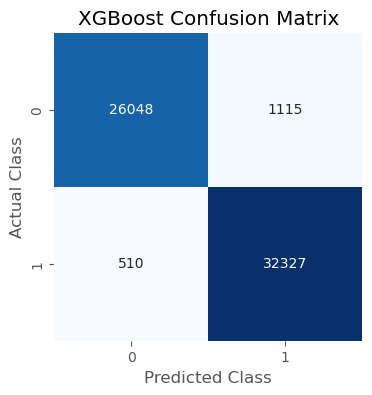

In [180]:
plot_confusion_matrix(y_test=y_val, y_predict=y_predict_xgboost, title="XGBoost Confusion Matrix")

## 6.2 CatBoost

In [149]:
def compute_catboost_errors(learning_rates=[], iterations=[], depths=[]):
    errors = []

    for lr, iterate, depth in zip(learning_rates, iterations, depths):
        # Build CatBoostClassifier with random seed = 100
        model_catboost = CatBoostClassifier(
            iterations=iterate,
            depth=depth,        
            learning_rate=lr,
            random_seed=100,
            verbose=0,
        ) 
        model_catboost.fit(X_train, y_train)
        y_predict = model_catboost.predict(X_val)
        
        accuracy = accuracy_score(y_val, y_predict)
        errors.append(1 - accuracy)
        
    return errors

### 6.2.1 CatBoost: Effect of learning rate

First, to determine a suitable learning rate for the subsequent steps, we compare five different learning rates using iterations = 100 (default is 1000, but we use 100 for faster testing) and depth = 6 (default). We then select the learning rate that minimizes the error, which will be used for the remaining steps.

In [150]:
learning_rates = [0.01, 0.05, 0.1, 0.3, 0.5]
iterations = [100] * len(learning_rates)
depths = [6] * len(learning_rates)

learning_rate_errors = compute_catboost_errors(
    learning_rates=learning_rates,
    iterations=iterations,
    depths=depths
)

In [151]:
for idx, e in enumerate(learning_rate_errors):
    print(f"With learning rate: {learning_rates[idx]}, accuracy: {(1 - e) * 100:.3f}%")

With learning rate: 0.01, accuracy: 88.980%
With learning rate: 0.05, accuracy: 97.270%
With learning rate: 0.1, accuracy: 97.287%
With learning rate: 0.3, accuracy: 97.283%
With learning rate: 0.5, accuracy: 97.285%


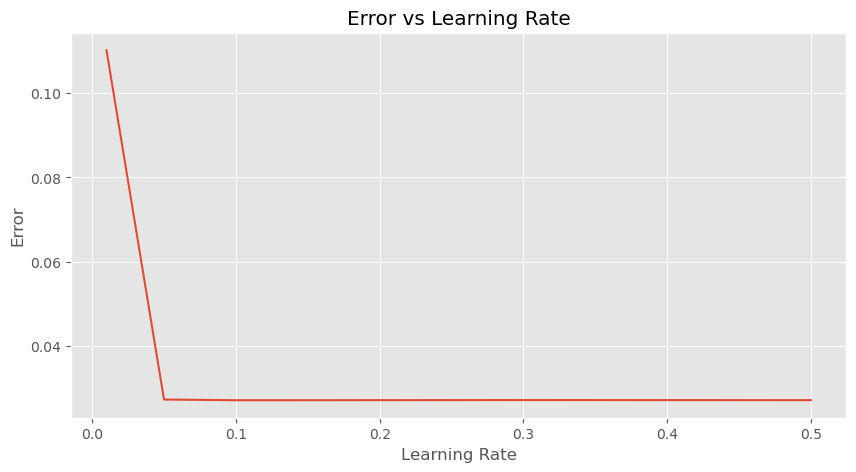

In [152]:
plot_error_curve(
    X=learning_rates,
    y=learning_rate_errors,
    x_label="Learning Rate",
    y_label="Error",
    title="Error vs Learning Rate"
)

In [153]:
cat_lr = 0.1 # best learning rate

Although lr = 0.5 gives the highest accuracy in this case, it may be less reliable in other scenarios. Therefore, we use lr = 0.1, which has only a very small difference in accuracy but is more stable.

### 6.2.2 CatBoost: Effect of iterations

In this section, we compare the effect of different iterations using the learning rate lr = 0.1 (selected in the previous section) and the default max_depth = 6.

In [154]:
iterations = [10, 50, 100, 150, 300]
learning_rates = [cat_lr] * len(iterations)
depths = [6] * len(iterations)

iter_errors = compute_catboost_errors(
    learning_rates=learning_rates,
    iterations=iterations,
    depths=depths
)

In [155]:
for idx, e in enumerate(iter_errors):
    print(f"With iterations: {iterations[idx]}, accuracy: {(1 - e) * 100:.3f}%")

With iterations: 10, accuracy: 88.982%
With iterations: 50, accuracy: 97.253%
With iterations: 100, accuracy: 97.287%
With iterations: 150, accuracy: 97.285%
With iterations: 300, accuracy: 97.258%


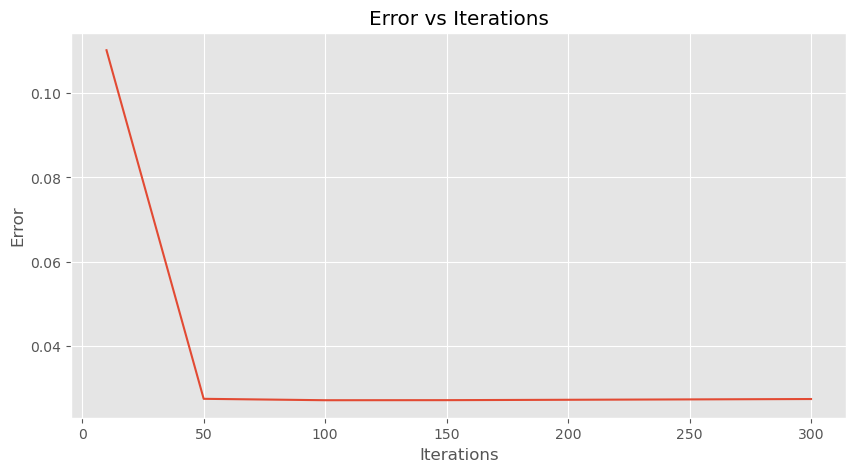

In [156]:
plot_error_curve(
    X=iterations,
    y=iter_errors,
    x_label="Iterations",
    y_label="Error",
    title="Error vs Iterations"
)

In [157]:
cat_iter = 150 # best iterations

As we can see, the error is highest when iterations = 10, then decreases significantly as the number of iterations increases, reaching a near-optimal value around iterations = 100–150. The error decreases slightly further at iterations = 300, but the difference is minimal. Therefore, we will use iterations = 150 for the subsequent steps for better stability.

### 6.2.3 CatBoost: Effect of depth

In this section, we compare the effect of different values of max_depth using the learning rate lr = 0.1 and iterations = 150 (selected in the previous section).

In [158]:
depths = [2, 4, 6, 8, 10]
iterations = [cat_iter] * len(depths)
learning_rates = [cat_lr] * len(depths)

depth_errors = compute_catboost_errors(
    learning_rates=learning_rates,
    iterations=iterations,
    depths=depths
)

In [159]:
for idx, e in enumerate(depth_errors):
    print(f"With depth: {depths[idx]}, accuracy: {(1 - e) * 100:.3f}%")

With depth: 2, accuracy: 94.395%
With depth: 4, accuracy: 97.293%
With depth: 6, accuracy: 97.285%
With depth: 8, accuracy: 97.297%
With depth: 10, accuracy: 97.248%


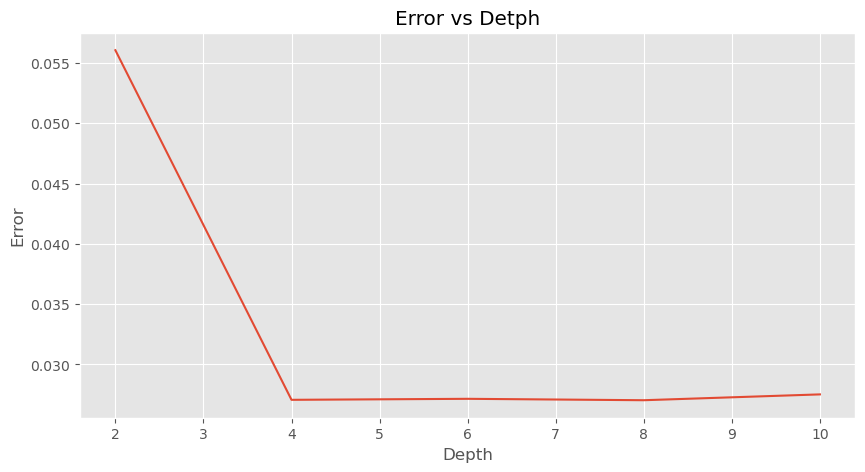

In [160]:
plot_error_curve(
    X=depths,
    y=depth_errors,
    x_label="Depth",
    y_label="Error",
    title="Error vs Detph"
)

In [161]:
cat_depth = 10 # best depth

As we can see, the error is highest when depth = 2, then decreases significantly as depth increases, reaching its lowest value at depth = 10. Therefore, we will use depth = 10 for the subsequent steps.

### 6.2.4 Best model of Catboost

In [185]:
model_catboost = CatBoostClassifier(
    iterations=cat_iter,
    depth=cat_depth,
    learning_rate=cat_lr,
    random_seed=100,
    verbose=False
)
model_catboost.fit(X_train, y_train)
y_predict_catboost = model_catboost.predict(X_val)
        
accuracy = accuracy_score(y_predict_catboost, y_val)
print(f"Accuracy of CatBoost: {accuracy*100:.5f}%")

Accuracy of CatBoost: 97.24833%


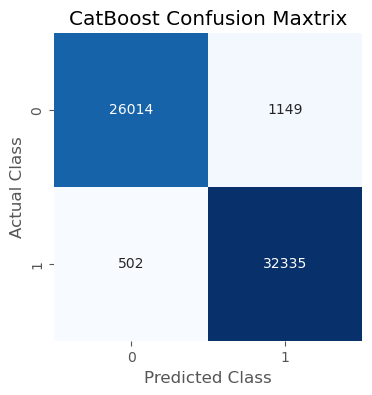

In [181]:
plot_confusion_matrix(y_test=y_val, y_predict=y_predict_catboost, title="CatBoost Confusion Maxtrix")

## 6.3 Compare XGBoost And CatBoost (Test Set)

In [190]:
y_predict_xgboost = model_xgboost.predict(X_test)
accuracy_xgboost = accuracy_score(y_test, y_predict_xgboost)
print(f"Accuracy of XGBoost (Test set): {accuracy_xgboost*100:.5f}%")

y_predict_catboost = model_catboost.predict(X_test)
accuracy_catboost = accuracy_score(y_test, y_predict_catboost)
print(f"Accuracy of CatBoost (Test set): {accuracy_catboost*100:.5f}%")

Accuracy of XGBoost (Test set): 97.24167%
Accuracy of CatBoost (Test set): 97.22833%


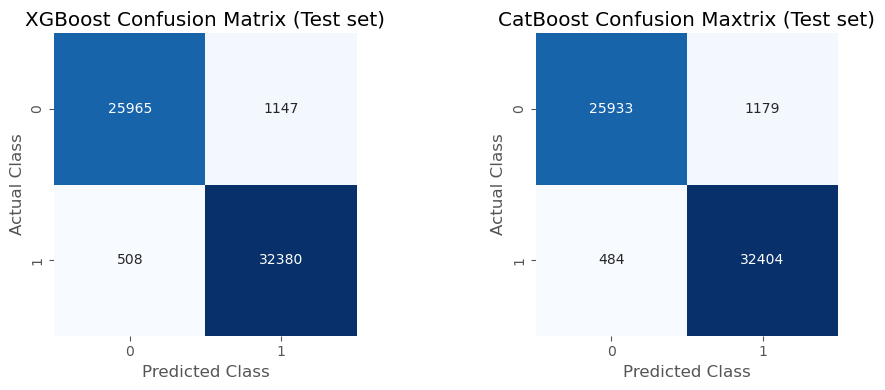

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion_matrix(y_test=y_test, y_predict=y_predict_xgboost, title="XGBoost Confusion Matrix (Test set)", ax=axes[0])
plot_confusion_matrix(y_test=y_test, y_predict=y_predict_catboost, title="CatBoost Confusion Maxtrix (Test set)", ax=axes[1])
plt.tight_layout()
plt.show()

### 6.3.1 Performance Overview
Both models demonstrate strong and consistent performance, with nearly identical accuracy on the test set:

- **XGBoost Accuracy:** 97.24% (slightly higher)  
- **CatBoost Accuracy:** 97.23%

---

### 6.3.2 Confusion Matrix Analysis
The table below summarizes the key differences in prediction outcomes:

| Metric | Class | XGBoost | CatBoost | Difference |
| :--- | :--- | :--- | :--- | :--- |
| **True Negatives (TN)** | 0 | **25,965** | 25,933 | XGBoost +32 |
| **False Positives (FP)** | 0 | **1,147** | 1,179 | XGBoost −32 (Better) |
| **False Negatives (FN)** | 1 | 508 | **484** | CatBoost −24 (Better) |
| **True Positives (TP)** | 1 | 32,380 | **32,404** | CatBoost +24 |

---

### 6.3.4 Conclusion
Each model has different advantages depending on the objective:

- **Choose XGBoost** when minimizing **False Positives** is the priority.  
- **Choose CatBoost** when minimizing **False Negatives** is more critical.
